In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import math
import random
import seaborn as sns
import matplotlib.pyplot as plt
# Sirve para medir la velocidad de una función
import time
%load_ext line_profiler
import sys
sys.path.insert(1, '/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Codigos/Funciones_utiles_f')
import funciones_aux_bootstrap_f_r as fab
from scipy.stats import variation

# Bootstrap por Submuestra de Votos - Método 2

**Nota**: Este notebook es parte del **Paso 2** del flujo de ejecución del proyecto.

**Requisitos previos**:
- Haber ejecutado: `Codigos/Codigo_creacion_base_analisis/Creacion_base_analsis.ipynb`
- Archivo de entrada: `Bases/Base elecciones analsis/base_elecciones_yuc_analsis.csv`

**Salida**:
- Resultados guardados en: `Bases finales rep/Bootstrap votos/Metodo 2/`

Para más información sobre el flujo completo, consultar el `README.md` del repositorio.

Este método de bootstrap (bayesiano) por votos consiste en lo siguiente

1. Se muestrea $n$ casillas.
2. De las $n$ casillas se muestrean $k$ votos para cada una de las $(1000)$ poblaciones distintas. Es decir, se obtiene un total de $1000$ muestras distintas de votos.
3. Para cada población y cada una de las $1000$ muestras de votos de tamaño $k$ se calculan los pesos Dirichlet, por lo tanto, se calculan en total $k*1000$ distintos pesos Dirichlet.
4. Se completan $1000$ poblaciones.
5. Con las poblaciones se obtienen la estimación puntual.

Se repite este proceso para $l$ bootstraps (normalmente son 1000) y con estos bootstraps se obtienen todas las métricas (errores, tamaño de los intervalos, coberturas, etc).

In [5]:
# Importamos los datos para el análisis
df_act_yuc_i=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Base elecciones analsis/base_elecciones_yuc_analsis.csv", index_col=0)
df_act_yuc_i

,ID ESTADO,NOMBRE ESTADO,DISTRITO,SECCION,CASILLA,ID CASILLA,ESTATUS ACTA,PAN,PRI,PRD,...,CANDIDATOS NO REGISTRADOS,VOTOS NULOS,LISTA NOMINAL,TOTAL,PARTICIPACIÓN,JOAQUIN_DIAZ_MENA,RENAN_BARRERA_CONCHA,VIDA_ARAVARI_GOMEZ_HERRERA,YAMIL_JASMIN_LOPEZ_MANRIQUE,VOTOS_NULOS_CAND_NO_REGIS
0,31,YUCATÁN,12,1,'0001B1,1,COMPUTADA,171.0,107.0,3.0,...,0.0,12.0,596.0,532.0,0.892617,209.0,290.0,18.0,3.0,12.0
1,31,YUCATÁN,12,1,'0001C1,2,COMPUTADA,177.0,104.0,0.0,...,0.0,11.0,596.0,547.0,0.917785,208.0,299.0,29.0,0.0,11.0
2,31,YUCATÁN,12,1,'0001C2,3,COMPUTADA,176.0,100.0,1.0,...,0.0,13.0,595.0,542.0,0.910924,228.0,289.0,11.0,1.0,13.0
3,31,YUCATÁN,12,2,'0002B1,4,COMPUTADA,46.0,33.0,2.0,...,0.0,3.0,174.0,162.0,0.931034,71.0,79.0,7.0,2.0,3.0
4,31,YUCATÁN,12,4,'0004B1,6,COMPUTADA,110.0,96.0,7.0,...,0.0,14.0,550.0,513.0,0.932727,275.0,207.0,10.0,7.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2836,31,YUCATÁN,3,1195,'1195V1,2967,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.000000,0.0,2.0,0.0,0.0,0.0
2837,31,YUCATÁN,5,1197,'1197V1,2969,COMPUTADA,2.0,1.0,0.0,...,0.0,0.0,0.0,5.0,0.000000,2.0,3.0,0.0,0.0,0.0
2838,31,YUCATÁN,8,1199,'1199V1,2971,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.000000,1.0,2.0,0.0,0.0,0.0
2839,31,YUCATÁN,9,1200,'1200V1,2972,COMPUTADA,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0


In [6]:
# Datos reales de la proporción
prop_reales=df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum()/df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum()
prop_reales

JOAQUIN_DIAZ_MENA              0.515125
RENAN_BARRERA_CONCHA           0.421366
VIDA_ARAVARI_GOMEZ_HERRERA     0.036792
YAMIL_JASMIN_LOPEZ_MANRIQUE    0.005249
VOTOS_NULOS_CAND_NO_REGIS      0.021467
dtype: float64

## Sin estratificar

In [ ]:
def bootstrap_votos_simple_met_2(df, num_boot: int=1000, n_sample=None, n_vot_sub=2000, semilla=1):

    est_punt_list=[]

    inter_list=[]

    # Número total de votos
    n_votos=int(df[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum())

    # Semilla para las muestras de la Dirichlet
    rng = np.random.default_rng()

    # Semilla para los conteos de votos (eventualmente se tiene que mover adentro del for para que sea reproducible el código)
    rng_2 = np.random.default_rng()

    for i in range(num_boot):

        # Semilla para que el código sea reproducible
        # Cambiamos el valor en el for
        rng = np.random.default_rng((num_boot*semilla)+i+1)

        df_stra_sam = df.sample(n=n_sample, random_state= rng)

        df_stra_sam=np.array(df_stra_sam[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]])

        # Semilla para las muestras de la Dirichlet
        rng = np.random.default_rng((i+1)+(num_boot*(semilla+1)))
 
        # Submuestra de votos (en este caso son 2000)
        # Corrección del código inicial lo correcto es utilizar la distribución hipergeométrica multivariada.
        # Puesto que, se esta haciendo muestreo sin reemplazo y si utilizas la multinomial es muestreo con reemplazo.
        # La diferencia es mínima pero la hipergeométrica multivariada es la correcta.
        # Sacamos 1000 muestras distintas
        votos_subm=rng.multivariate_hypergeometric(colors=df_stra_sam.sum(0).astype(int), nsample=n_vot_sub, size=1000)

        # Los pesos de la distribución Dirichlet para las 1000 muestras distintas
        pesos_bootstrap=fab.dirichlet_sample(votos_subm, semilla=(i+1)+(num_boot*(semilla+2)))

        # Semilla para las muestras de la Dirichlet
        rng = np.random.default_rng((i+1)+(num_boot*(semilla+3)))

        # Simulamos las 1000 poblaciones de votos
        votos_sim=rng.multinomial(n=n_votos,  pvals=pesos_bootstrap)

        # Obtenemos las proporciones de los votos
        array_res=(votos_sim)/n_votos

        # Los valores de los intervalos de probabilidad lower y upper
        inter_prob=np.concatenate((np.apply_along_axis(fab.inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(fab.inter_prob_u, axis=0, arr=array_res)))
        
        # Estimaciones puntuales
        est_puntual=array_res.mean(0)

        # Guardamos las estimaciones puntuales
        est_punt_list.append(est_puntual)

        # Guardamos los intervalos
        inter_list.append(inter_prob)
        
    print(df_stra_sam.shape[0])
    
    # Todas las estimaciones puntuales
    array_est_punt=np.array(est_punt_list)

    array_inter_prob=np.array(inter_list)

    return array_inter_prob,array_est_punt


In [25]:
# Boostrap por votos
inter_prob_v, est_punt_v=bootstrap_votos_simple_met_2(df_act_yuc_i, num_boot=1000, n_sample=350, n_vot_sub=15000, semilla=21)

350


In [9]:
# Para medir cuanto tiempo se tarda en correr en promedio
%timeit bootstrap_votos_simple_met_2(df_act_yuc_i, num_boot=1000, n_sample=250, n_vot_sub=5000)

250
250
250
250
250
250
250
250
2.18 s ± 282 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [27]:
# Guardamos las bases
df_metr_boot_v, df_error_max_v, df_can_cob_v = fab.metricas_bootstrap(prop_reales, inter_prob_v, est_punt_v, porcenta_tama=15000)

In [28]:
df_metr_boot_v.groupby(["Candidato"]).agg({'Longitud_intervalo':['median','mean']})

Longitud_intervalo          
                                        median      mean
Candidato                                               
JOAQUIN_DIAZ_MENA                     0.021990  0.021977
RENAN_BARRERA_CONCHA                  0.021709  0.021713
VIDA_ARAVARI_GOMEZ_HERRERA            0.008266  0.008276
VOTOS_NULOS_CAND_NO_REGIS             0.006391  0.006391
YAMIL_JASMIN_LOPEZ_MANRIQUE           0.003162  0.003171

In [29]:
df_can_cob_v

,Candidato,Numero_total_cob,Cobertura,Porcenta_tama
0,JOAQUIN_DIAZ_MENA,879,0.879,15000
1,RENAN_BARRERA_CONCHA,865,0.865,15000
2,VIDA_ARAVARI_GOMEZ_HERRERA,965,0.965,15000
3,VOTOS_NULOS_CAND_NO_REGIS,1000,1.000,15000
4,YAMIL_JASMIN_LOPEZ_MANRIQUE,990,0.990,15000


In [10]:
df_error_max_v.describe(percentiles=[0.025,0.975])

,Num_bootstrap,Error_max,Porcenta_tama
count,1000.000000,1000.000000,1000.0
mean,500.500000,0.006729,2000.0
std,288.819436,0.004225,0.0
min,1.000000,0.000224,2000.0
2.5%,25.975000,0.001132,2000.0
50%,500.500000,0.005805,2000.0
97.5%,975.025000,0.016544,2000.0
max,1000.000000,0.024475,2000.0


In [36]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v=df_metr_boot_v.drop(columns="Cobertura").merge(df_can_cob_v[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.497917,0.516455,0.018538,0.506746,0.515125,JOAQUIN_DIAZ_MENA,0.008379,2000,0.798
1,2,0.506466,0.525816,0.019350,0.516061,0.515125,JOAQUIN_DIAZ_MENA,0.000935,2000,0.798
2,3,0.514976,0.533242,0.018266,0.523933,0.515125,JOAQUIN_DIAZ_MENA,0.008808,2000,0.798
3,4,0.510590,0.529024,0.018435,0.519539,0.515125,JOAQUIN_DIAZ_MENA,0.004414,2000,0.798
4,5,0.507238,0.526120,0.018881,0.516748,0.515125,JOAQUIN_DIAZ_MENA,0.001622,2000,0.798
...,...,...,...,...,...,...,...,...,...,...
4995,996,0.018204,0.023671,0.005467,0.020913,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000554,2000,0.994
4996,997,0.017815,0.023491,0.005676,0.020554,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000913,2000,0.994
4997,998,0.017623,0.022900,0.005278,0.020295,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001172,2000,0.994
4998,999,0.018788,0.024026,0.005238,0.021322,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000145,2000,0.994


In [23]:
# Candidato con intervalo más largo
df_inter_lar_v=df_metr_boot_v.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v["Porcenta_tama"]=250
candidato_mas_largo_v=df_inter_lar_v[df_inter_lar_v["Longitud_intervalo"]==df_inter_lar_v["Longitud_intervalo"].max()]["Candidato"].values[0]
df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v]["Longitud_intervalo"].describe(percentiles=[0.025, 0.5, 0.975])

count    1000.000000
mean        0.038722
std         0.001212
min         0.034399
2.5%        0.036395
50%         0.038701
97.5%       0.041156
max         0.044558
Name: Longitud_intervalo, dtype: float64

In [24]:
# Candidato con intervalo más largo
df_inter_lar_v=df_metr_boot_v.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v["Porcenta_tama"]=250
candidato_mas_largo_v=df_inter_lar_v[df_inter_lar_v["Longitud_intervalo"]==df_inter_lar_v["Longitud_intervalo"].max()]["Candidato"].values[0]

In [25]:
# Candidato con menor cobertura
candidato_cober_men_v=df_can_cob_v[df_can_cob_v["Cobertura"]==df_can_cob_v["Cobertura"].min()]["Candidato"].values[0]

In [ ]:
df_error_max_v.describe(percentiles=[0.025,0.975])

,Num_bootstrap,Error_max,Porcenta_tama
count,1000.000000,1000.000000,1000.0
mean,500.500000,0.007951,2000.0
std,288.819436,0.005170,0.0
min,1.000000,0.000644,2000.0
2.5%,25.975000,0.001336,2000.0
50%,500.500000,0.006560,2000.0
97.5%,975.025000,0.020085,2000.0
max,1000.000000,0.029391,2000.0


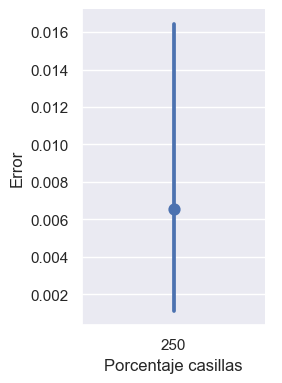

In [27]:
sns.set_theme();
ax = sns.catplot(
    data=df_error_max_v, x="Porcenta_tama", y="Error_max",
    kind="point", height=4, aspect=.7, errorbar='pi'
);
ax.set(xlabel='Porcentaje casillas', ylabel='Error');

In [28]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v=df_metr_boot_v.drop(columns="Cobertura").merge(df_can_cob_v[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.500934,0.539530,0.038597,0.520057,0.515125,JOAQUIN_DIAZ_MENA,0.004931,250,0.993
1,2,0.498908,0.537580,0.038672,0.518588,0.515125,JOAQUIN_DIAZ_MENA,0.003463,250,0.993
2,3,0.499795,0.536926,0.037132,0.517986,0.515125,JOAQUIN_DIAZ_MENA,0.002860,250,0.993
3,4,0.493333,0.532270,0.038937,0.513111,0.515125,JOAQUIN_DIAZ_MENA,0.002015,250,0.993
4,5,0.503355,0.539387,0.036032,0.521709,0.515125,JOAQUIN_DIAZ_MENA,0.006584,250,0.993
...,...,...,...,...,...,...,...,...,...,...
4995,996,0.015532,0.026582,0.011050,0.020763,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000704,250,1.000
4996,997,0.014709,0.025144,0.010435,0.019535,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001933,250,1.000
4997,998,0.016700,0.028122,0.011422,0.022067,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000600,250,1.000
4998,999,0.015447,0.026751,0.011304,0.020854,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000613,250,1.000


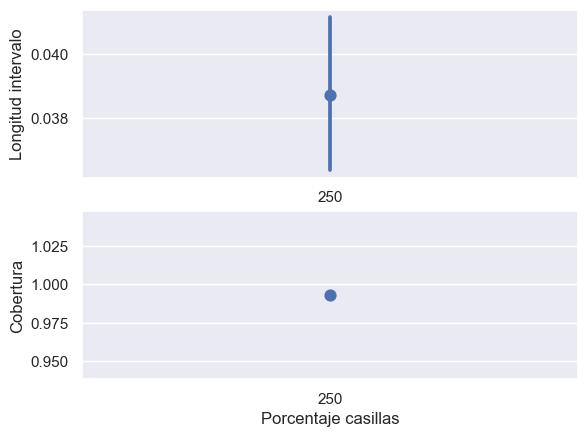

In [29]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi',ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');


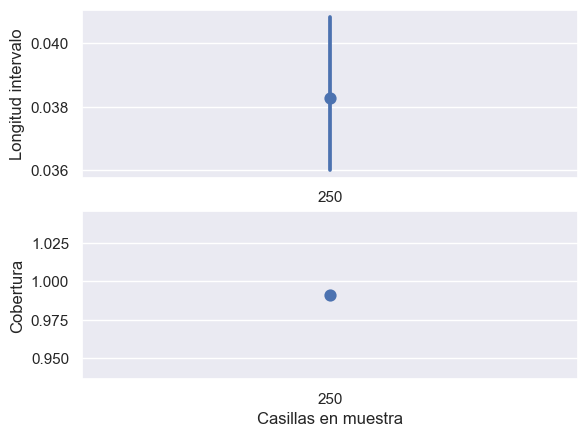

In [30]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_cober_men_v], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi', ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_cober_men_v].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Casillas en muestra', ylabel='Longitud intervalo');
ax_2.set(xlabel='Casillas en muestra', ylabel='Cobertura');

In [62]:
# Probamos distintos valores de tamaño de la muestra de las casillas y la submuestra de votos
muestra_casillas = [100, 150, 200, 250, 300, 350, 400]
#submuestra_votos = [500, 1000, 1500, 2000, 3000, 4000]

# Edición especial con otras submuestras de votos
submuestra_votos = [500, 1000, 2000, 5000, 10000, 20000]

# Dataframe donde se guardará todo
df_boostraps_votos_se=pd.DataFrame()

# Contador para el for
k=0

for mc in muestra_casillas:
    for smv in submuestra_votos:
        # Boostrap por votos (sin estratificar)
        inter_prob_v, est_punt_v=bootstrap_votos_simple_met_2(df_act_yuc_i, num_boot=1000, n_sample=mc, n_vot_sub=smv, semilla=k+1)
        # Calculamos las métricas
        df_metr_boot_v, df_error_max_v, df_can_cob_v = fab.metricas_bootstrap(prop_reales, inter_prob_v, est_punt_v, porcenta_tama=mc)

        # Los valores de las muestra y submuestras
        df_boostraps_votos_se.loc[k,["Tamaño_muestra_casillas","Tamaño_submuestra_votos"]]=[mc,smv]

        # Las métricas para el error máximo
        df_boostraps_votos_se.loc[k,["Error_maximo_q_025","Error_maximo_mediana","Error_maximo_q_975"]]=df_error_max_v["Error_max"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato que tenga intervalos más largos (en promedio)
        candidato_int_m_l=df_metr_boot_v.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()["Candidato"].values[0]
        # Candidato con el intervalos más grandes
        df_boostraps_votos_se.loc[k, "Intervalo_M_grande_candidato_nom"]=candidato_int_m_l
        # Cobertura del candidato con el intervalos más grandes
        df_boostraps_votos_se.loc[k, ["Intervalo_M_grande_candidato_cob"]]=df_can_cob_v[df_can_cob_v["Candidato"]==candidato_int_m_l]["Cobertura"].values[0]
        # Las métricas del candidato con los intervalos más grandes
        df_boostraps_votos_se.loc[k,["Intervalo_M_grande_inter_q_025","Intervalo_M_grande_inter_mediana","Intervalo_M_grande_inter_q_975"]]=df_metr_boot_v[df_metr_boot_v["Candidato"]==candidato_int_m_l]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato con la menor cobertura
        # Candidato con menor cobertura
        candidato_cober_men_v=df_can_cob_v[df_can_cob_v["Cobertura"]==df_can_cob_v["Cobertura"].min()]["Candidato"].values[0]

        # Candidato con el intervalos más grandes
        df_boostraps_votos_se.loc[k, "Cobertura_m_candidato_nom"]=candidato_cober_men_v
        # Cobertura del candidato con menor cobertura
        df_boostraps_votos_se.loc[k, ["Cobertura_m_candidato"]]=df_can_cob_v[df_can_cob_v["Candidato"]==candidato_cober_men_v]["Cobertura"].values[0]
        # Las métricas del candidato con la menor cobertura
        df_boostraps_votos_se.loc[k,["Cobertura_m_inter_q_025","Cobertura_m_inter_mediana","Cobertura_m_inter_q_975"]]=df_metr_boot_v[df_metr_boot_v["Candidato"]==candidato_cober_men_v]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        
        # Coberturas de los candidatos en el bootstrap 
        df_boostraps_votos_se.loc[k, ["Cob_JOAQUIN_DIAZ_MENA","Cob_RENAN_BARRERA_CONCHA","Cob_VIDA_ARAVARI_GOMEZ_HERRERA","Cob_VOTOS_NULOS_CAND_NO_REGIS","Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"]]=df_can_cob_v.sort_values(by="Candidato")["Cobertura"].to_list()

        k=k+1
        
        print("Muestra casillas:", mc, "Submuestra votos:", smv)

100
Muestra casillas: 100 Submuestra votos: 500
100
Muestra casillas: 100 Submuestra votos: 1000
100
Muestra casillas: 100 Submuestra votos: 2000
100
Muestra casillas: 100 Submuestra votos: 5000
100
Muestra casillas: 100 Submuestra votos: 10000
100
Muestra casillas: 100 Submuestra votos: 20000
150
Muestra casillas: 150 Submuestra votos: 500
150
Muestra casillas: 150 Submuestra votos: 1000
150
Muestra casillas: 150 Submuestra votos: 2000
150
Muestra casillas: 150 Submuestra votos: 5000
150
Muestra casillas: 150 Submuestra votos: 10000
150
Muestra casillas: 150 Submuestra votos: 20000
200
Muestra casillas: 200 Submuestra votos: 500
200
Muestra casillas: 200 Submuestra votos: 1000
200
Muestra casillas: 200 Submuestra votos: 2000
200
Muestra casillas: 200 Submuestra votos: 5000
200
Muestra casillas: 200 Submuestra votos: 10000
200
Muestra casillas: 200 Submuestra votos: 20000
250
Muestra casillas: 250 Submuestra votos: 500
250
Muestra casillas: 250 Submuestra votos: 1000
250
Muestra casill

In [65]:
df_boostraps_votos_se

,Tamaño_muestra_casillas,Tamaño_submuestra_votos,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE
0,100,500,0.002173,0.011172,0.032679,JOAQUIN_DIAZ_MENA,1.000,0.115073,0.122495,0.130001,JOAQUIN_DIAZ_MENA,1.000,0.115073,0.122495,0.130001,1.000,1.000,1.000,1.000,1.000
1,100,1000,0.002283,0.010349,0.032449,JOAQUIN_DIAZ_MENA,0.998,0.081713,0.086576,0.091701,JOAQUIN_DIAZ_MENA,0.998,0.081713,0.086576,0.091701,0.998,0.998,1.000,1.000,1.000
2,100,2000,0.002293,0.011880,0.034574,JOAQUIN_DIAZ_MENA,0.967,0.057437,0.060915,0.064651,RENAN_BARRERA_CONCHA,0.958,0.056892,0.060336,0.063914,0.967,0.958,0.997,1.000,1.000
3,100,5000,0.002379,0.011266,0.033060,JOAQUIN_DIAZ_MENA,0.850,0.035849,0.037839,0.040324,RENAN_BARRERA_CONCHA,0.821,0.035225,0.037359,0.039738,0.850,0.821,0.934,0.994,0.978
4,100,10000,0.002256,0.010593,0.033217,JOAQUIN_DIAZ_MENA,0.686,0.024456,0.025995,0.027541,RENAN_BARRERA_CONCHA,0.663,0.024158,0.025618,0.027231,0.686,0.663,0.787,0.966,0.895
5,100,20000,0.002130,0.010973,0.031689,JOAQUIN_DIAZ_MENA,0.492,0.016236,0.017153,0.018144,RENAN_BARRERA_CONCHA,0.463,0.015958,0.016928,0.017911,0.492,0.463,0.571,0.908,0.677
6,150,500,0.001702,0.009210,0.025388,JOAQUIN_DIAZ_MENA,1.000,0.115588,0.122782,0.129911,JOAQUIN_DIAZ_MENA,1.000,0.115588,0.122782,0.129911,1.000,1.000,1.000,1.000,1.000
7,150,1000,0.001792,0.008999,0.026553,JOAQUIN_DIAZ_MENA,1.000,0.081676,0.086830,0.091893,JOAQUIN_DIAZ_MENA,1.000,0.081676,0.086830,0.091893,1.000,1.000,1.000,1.000,1.000
8,150,2000,0.001600,0.009181,0.026071,JOAQUIN_DIAZ_MENA,0.997,0.057647,0.061172,0.064851,RENAN_BARRERA_CONCHA,0.995,0.056779,0.060393,0.064432,0.997,0.995,1.000,1.000,1.000
9,150,5000,0.001700,0.009032,0.026154,JOAQUIN_DIAZ_MENA,0.924,0.036054,0.038235,0.040507,RENAN_BARRERA_CONCHA,0.909,0.035584,0.037786,0.040026,0.924,0.909,0.975,0.998,0.995


In [ ]:
# Guardamos en un csv
#df_boostraps_votos_se.to_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap votos/Metodo 2/Distintas_muestras_submuestras_bootstrap_votos_met_2_sin_est_f_1.csv")

## Estratificado (por distrito)

In [ ]:
# Versión función
def boot_votos_estratificado_met_2(df_act_yuc_i, num_boot: int=1000, n_sample=None, n_vot_sub=2000, semilla=1):

    # Listas auxiliares para guardar los datos
    est_punt_list=[]

    inter_list=[]

    # Cuantas votos hay por distrito
    array_frec_est=np.array(df_act_yuc_i.groupby('DISTRITO').agg({'TOTAL':'sum'}).reset_index(drop=True).astype(int)["TOTAL"])

    # Número de poblaciones
    n_boot=1000

    # Semilla para las muestras de la Dirichlet
    rng = np.random.default_rng()

    # Semilla para las muestras de la Dirichlet
    rng_2 = np.random.default_rng()

    # Los valores distintos de los distritos
    val_dist=df_act_yuc_i["DISTRITO"].sort_values().unique()

    for i in range(num_boot):

        # Hacemos el muestreo de tamaño n_sample de las casilas estratificado por distrito
        df_stra_sam=fab.muestreo_estratificado_mej(df_act_yuc_i, ["DISTRITO"], sample_size=n_sample, semilla=i+1+(num_boot*semilla))

        # Guardamos en un numpy array el dataframe de la muestra
        array_muest=np.array(df_stra_sam[["DISTRITO","JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]])

        # Corrección porque el muestreo estratificado es de votos
        # Porcentaje del total de votos por estrato (distrito)
        array_pesos_normalizados_dist=np.array(df_stra_sam.groupby('DISTRITO').agg({'TOTAL':'sum'}).div(df_stra_sam["TOTAL"].sum()).sort_index()["TOTAL"])

        # Obtenemos los totales de las proporciones para cada estrato (distrito)
        #totales_prop_est=fab.obtener_totales(array_pesos_normalizados_dist, n_vot_sub)
        totales_prop_est=fab.obtener_totales(array_pesos_normalizados_dist, n_vot_sub).astype(int)

        # Los porcentajes de cada distrito en la submuestra de votos
        array_pesos_normalizados_sub=totales_prop_est/totales_prop_est.sum()
        
        # array_frec_normalizados = array_frec_est/array_frec_est.sum()


        # Submuestra de votos por distrito (estrato)
        # Corrección del código inicial lo correcto es utilizar la distribución hipergeométrica multivariada.
        # Puesto que, se esta haciendo muestreo sin reemplazo y si utilizas la multinomial es muestreo con reemplazo.
        # La diferencia es mínima pero la hipergeométrica multivariada es la correcta.
        votos_subm_d=[np.random.default_rng(index+((i+1)+(num_boot*(semilla+1)))).multivariate_hypergeometric(colors=array_muest[array_muest[:,0]==val][:,1:].sum(0).astype(int), nsample=totales_prop_est[val-1], size=1000) for index, val in enumerate(val_dist)]

        # Vector de pesos de la distribución Dirichlet

        # Obtenemos los vectores Dirichlet para cada uno de los estratos
        vectores_dir=[fab.dirichlet_sample(xi, semilla=(i+1)+(num_boot*(semilla+2))) for xi in votos_subm_d]

        # Donde se van a guardar los resultados
        array_res=np.zeros((n_boot,5))

        # Completamos la muestra mediante el bootstrap bayesiano en cada estrato
        for k in val_dist:

            # Semilla para las muestras de la Multinomial
            rng_2 = np.random.default_rng((num_boot*(semilla+3))+(i+1+k))
            
            # Total de votos de la muestra simulada (utilizando una multinomial)
            votos_sim=rng_2.multinomial(n=array_frec_est[k-1],  pvals=vectores_dir[k-1])

            # Guardamos todo en un array con las estimaciones (se van sumando las iteraciones para alcnazar el 100%)
            array_res=array_res+(votos_sim/votos_sim.sum(1)[0]*array_pesos_normalizados_sub[k-1])
                
        # Los valores de los intervalos de probabilidad lower y upper
        inter_prob=np.concatenate((np.apply_along_axis(fab.inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(fab.inter_prob_u, axis=0, arr=array_res)))

        # Estimaciones puntuales (del bootstrap)
        est_puntual=array_res.mean(0)

        # Guardamos las estimaciones puntuales
        est_punt_list.append(est_puntual)

        # Guardamos los intervalos
        inter_list.append(inter_prob)


    print(df_stra_sam.shape[0])
    
    # Todas las estimaciones puntuales
    array_est_punt=np.array(est_punt_list)

    array_inter_prob=np.array(inter_list)
    
    return array_inter_prob,array_est_punt


In [11]:
inter_prob_v_est, est_punt_v_est=boot_votos_estratificado_met_2(df_act_yuc_i, num_boot=1000, n_sample=350, n_vot_sub=15000, semilla=11)

350


In [10]:
# Para medir cuanto tiempo se tarda en correr en promedio
%timeit boot_votos_estratificado_met_2(df_act_yuc_i, num_boot=1000, n_sample=250, n_vot_sub=5000)

250
250
250
250
250
250
250
250
21.5 s ± 455 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [12]:
# Cálculamos las métricas
df_metr_boot_v_est, df_error_max_v_est, df_can_cob_v_est = fab.metricas_bootstrap(prop_reales, inter_prob_v_est, est_punt_v_est, porcenta_tama=2000)

In [13]:
df_can_cob_v_est

,Candidato,Numero_total_cob,Cobertura,Porcenta_tama
0,JOAQUIN_DIAZ_MENA,961,0.961,2000
1,RENAN_BARRERA_CONCHA,946,0.946,2000
2,VIDA_ARAVARI_GOMEZ_HERRERA,986,0.986,2000
3,VOTOS_NULOS_CAND_NO_REGIS,1000,1.000,2000
4,YAMIL_JASMIN_LOPEZ_MANRIQUE,997,0.997,2000


In [28]:
# 25th Percentile
def q025(x):
    return x.quantile(0.025)

# 97.5th Percentile
def q975(x):
    return x.quantile(0.975)

In [29]:
df_metr_boot_v_est.groupby(["Candidato"]).agg({'Longitud_intervalo':['median',q025,q975]})

Longitud_intervalo                    
                                        median      q025      q975
Candidato                                                         
JOAQUIN_DIAZ_MENA                     0.022278  0.020927  0.023729
RENAN_BARRERA_CONCHA                  0.021740  0.020362  0.023208
VIDA_ARAVARI_GOMEZ_HERRERA            0.008588  0.007971  0.009315
VOTOS_NULOS_CAND_NO_REGIS             0.006669  0.006223  0.007207
YAMIL_JASMIN_LOPEZ_MANRIQUE           0.003339  0.002904  0.003966

In [18]:
# Candidato con intervalo más largo
df_inter_lar_v_est=df_metr_boot_v_est.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v_est["Porcenta_tama"]=250
candidato_mas_largo_v_est=df_inter_lar_v_est[df_inter_lar_v_est["Longitud_intervalo"]==df_inter_lar_v_est["Longitud_intervalo"].max()]["Candidato"].values[0]

In [19]:
# Candidato con menor cobertura
candidato_cober_men_v_est=df_can_cob_v_est[df_can_cob_v_est["Cobertura"]==df_can_cob_v_est["Cobertura"].min()]["Candidato"].values[0]

In [57]:
df_error_max_v_est.describe(percentiles=[0.025,0.975])

,Num_bootstrap,Error_max,Porcenta_tama
count,1000.000000,1000.000000,1000.0
mean,500.500000,0.006420,2000.0
std,288.819436,0.004001,0.0
min,1.000000,0.000438,2000.0
2.5%,25.975000,0.001218,2000.0
50%,500.500000,0.005514,2000.0
97.5%,975.025000,0.015959,2000.0
max,1000.000000,0.022926,2000.0


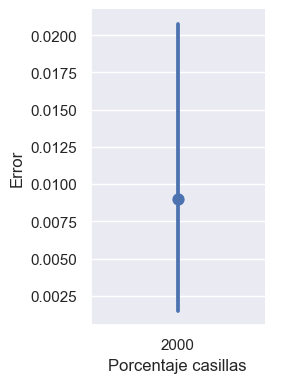

In [22]:
sns.set_theme();
ax = sns.catplot(
    data=df_error_max_v_est, x="Porcenta_tama", y="Error_max",
    kind="point", height=4, aspect=.7, errorbar='pi'
);
ax.set(xlabel='Porcentaje casillas', ylabel='Error');

In [23]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v_est=df_metr_boot_v_est.drop(columns="Cobertura").merge(df_can_cob_v_est[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v_est

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.483439,0.545137,0.061698,0.514090,0.515125,JOAQUIN_DIAZ_MENA,0.001036,2000,1.0
1,2,0.489626,0.548447,0.058821,0.518974,0.515125,JOAQUIN_DIAZ_MENA,0.003848,2000,1.0
2,3,0.505217,0.564621,0.059404,0.533615,0.515125,JOAQUIN_DIAZ_MENA,0.018490,2000,1.0
3,4,0.487398,0.545694,0.058296,0.515338,0.515125,JOAQUIN_DIAZ_MENA,0.000212,2000,1.0
4,5,0.495107,0.554717,0.059610,0.524354,0.515125,JOAQUIN_DIAZ_MENA,0.009228,2000,1.0
...,...,...,...,...,...,...,...,...,...,...
4995,996,0.013899,0.031260,0.017362,0.021950,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000483,2000,1.0
4996,997,0.014279,0.032357,0.018078,0.022751,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001284,2000,1.0
4997,998,0.012942,0.029950,0.017008,0.020905,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000562,2000,1.0
4998,999,0.012855,0.029553,0.016698,0.020379,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001088,2000,1.0


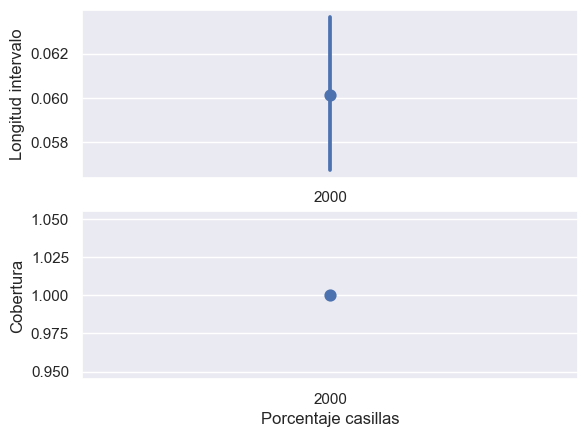

In [24]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_mas_largo_v_est], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi',ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_mas_largo_v_est].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');


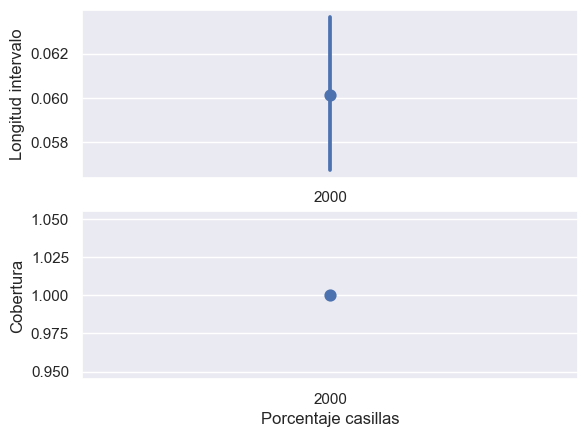

In [25]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_cober_men_v_est], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi', ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_cober_men_v_est].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');

In [68]:
# Probamos distintos valores de tamaño de la muestra de las casillas y la submuestra de votos
muestra_casillas = [100, 150, 200, 250, 300, 350, 400]
#submuestra_votos = [500, 1000, 1500, 2000, 3000, 4000]

# Edición especial con otras submuestras de votos
submuestra_votos = [500, 1000, 2000, 5000, 10000, 20000]

# Dataframe donde se guardará todo
df_boostraps_votos_ec=pd.DataFrame()

# Contador para el for
k=0

# Hacemos los for sobre el tamaño de las muestras y submuestras
for mc in muestra_casillas:
    for smv in submuestra_votos:
        # Para medir cuanto tiempo se tarda en correr
        loop_time = time.time()
        # Boostrap por votos (estratificado)
        inter_prob_v_est, est_punt_v_est=boot_votos_estratificado_met_2(df_act_yuc_i, num_boot=1000, n_sample=mc, n_vot_sub=smv, semilla=k+1)

        # Calculamos las métricas
        df_metr_boot_v_est, df_error_max_v_est, df_can_cob_v_est = fab.metricas_bootstrap(prop_reales, inter_prob_v_est, est_punt_v_est, porcenta_tama=mc)

        # Los valores de las muestra y submuestras
        df_boostraps_votos_ec.loc[k,["Tamaño_muestra_casillas","Tamaño_submuestra_votos"]]=[mc,smv]

        # Las métricas para el error máximo
        df_boostraps_votos_ec.loc[k,["Error_maximo_q_025","Error_maximo_mediana","Error_maximo_q_975"]]=df_error_max_v_est["Error_max"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato que tenga intervalos más largos (en promedio)
        candidato_int_est_m_l=df_metr_boot_v_est.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()["Candidato"].values[0]
        # Candidato con el intervalos más grandes
        df_boostraps_votos_ec.loc[k, "Intervalo_M_grande_candidato_nom"]=candidato_int_est_m_l
        # Cobertura del candidato con el intervalos más grandes
        df_boostraps_votos_ec.loc[k, ["Intervalo_M_grande_candidato_cob"]]=df_can_cob_v_est[df_can_cob_v_est["Candidato"]==candidato_int_est_m_l]["Cobertura"].values[0]
        # Las métricas del candidato con los intervalos más grandes
        df_boostraps_votos_ec.loc[k,["Intervalo_M_grande_inter_q_025","Intervalo_M_grande_inter_mediana","Intervalo_M_grande_inter_q_975"]]=df_metr_boot_v_est[df_metr_boot_v_est["Candidato"]==candidato_int_est_m_l]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato con la menor cobertura
        # Candidato con menor cobertura
        candidato_cober_est_men_v=df_can_cob_v_est[df_can_cob_v_est["Cobertura"]==df_can_cob_v_est["Cobertura"].min()]["Candidato"].values[0]

        # Candidato con el intervalos más grandes
        df_boostraps_votos_ec.loc[k, "Cobertura_m_candidato_nom"]=candidato_cober_est_men_v
        # Cobertura del candidato con menor cobertura
        df_boostraps_votos_ec.loc[k, ["Cobertura_m_candidato"]]=df_can_cob_v_est[df_can_cob_v_est["Candidato"]==candidato_cober_est_men_v]["Cobertura"].values[0]
        # Las métricas del candidato con la menor cobertura
        df_boostraps_votos_ec.loc[k,["Cobertura_m_inter_q_025","Cobertura_m_inter_mediana","Cobertura_m_inter_q_975"]]=df_metr_boot_v_est[df_metr_boot_v_est["Candidato"]==candidato_cober_est_men_v]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        # Coberturas de los candidatos en el bootstrap 
        df_boostraps_votos_ec.loc[k, ["Cob_JOAQUIN_DIAZ_MENA","Cob_RENAN_BARRERA_CONCHA","Cob_VIDA_ARAVARI_GOMEZ_HERRERA","Cob_VOTOS_NULOS_CAND_NO_REGIS","Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"]]=df_can_cob_v_est.sort_values(by="Candidato")["Cobertura"].to_list()

        k=k+1
        
        print("Muestra casillas:", mc, "Submuestra votos:", smv)
        print('Tiempo que tarda correr una iteración del for {}'.format((time.time() - loop_time)))  

# Lo guardamos en otra base copia por si sin querer pongo a correr el código
df_boostraps_votos_ec_f=df_boostraps_votos_ec.copy()

100
Muestra casillas: 100 Submuestra votos: 500
Tiempo que tarda correr una iteración del for 14.995723724365234
100
Muestra casillas: 100 Submuestra votos: 1000
Tiempo que tarda correr una iteración del for 16.313000917434692
100
Muestra casillas: 100 Submuestra votos: 2000
Tiempo que tarda correr una iteración del for 17.753190994262695
100
Muestra casillas: 100 Submuestra votos: 5000
Tiempo que tarda correr una iteración del for 19.553949117660522
100
Muestra casillas: 100 Submuestra votos: 10000
Tiempo que tarda correr una iteración del for 21.068916082382202
100
Muestra casillas: 100 Submuestra votos: 20000
Tiempo que tarda correr una iteración del for 21.388230085372925
150
Muestra casillas: 150 Submuestra votos: 500
Tiempo que tarda correr una iteración del for 15.303123950958252
150
Muestra casillas: 150 Submuestra votos: 1000
Tiempo que tarda correr una iteración del for 16.93337607383728
150
Muestra casillas: 150 Submuestra votos: 2000
Tiempo que tarda correr una iteración de

In [69]:
df_boostraps_votos_ec_f

,Tamaño_muestra_casillas,Tamaño_submuestra_votos,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE
0,100,500,0.001908,0.008924,0.026292,JOAQUIN_DIAZ_MENA,1.000,0.111527,0.118423,0.126300,JOAQUIN_DIAZ_MENA,1.000,0.111527,0.118423,0.126300,1.000,1.000,1.000,1.000,1.000
1,100,1000,0.001896,0.008597,0.024234,JOAQUIN_DIAZ_MENA,1.000,0.079310,0.084238,0.089820,JOAQUIN_DIAZ_MENA,1.000,0.079310,0.084238,0.089820,1.000,1.000,1.000,1.000,1.000
2,100,2000,0.001882,0.008636,0.026597,JOAQUIN_DIAZ_MENA,0.991,0.055998,0.059617,0.063167,RENAN_BARRERA_CONCHA,0.987,0.055362,0.058762,0.062460,0.991,0.987,0.999,1.000,0.999
3,100,5000,0.001710,0.009112,0.025506,JOAQUIN_DIAZ_MENA,0.932,0.035176,0.037322,0.039569,RENAN_BARRERA_CONCHA,0.901,0.034536,0.036766,0.038942,0.932,0.901,0.965,0.989,0.980
4,100,10000,0.001901,0.008498,0.024674,JOAQUIN_DIAZ_MENA,0.789,0.024125,0.025714,0.027295,RENAN_BARRERA_CONCHA,0.765,0.023693,0.025250,0.026938,0.789,0.765,0.840,0.962,0.900
5,100,20000,0.001831,0.008520,0.025012,JOAQUIN_DIAZ_MENA,0.667,0.017302,0.019659,0.024081,RENAN_BARRERA_CONCHA,0.624,0.016699,0.018681,0.022679,0.667,0.624,0.710,0.940,0.808
6,150,500,0.001481,0.006700,0.021338,JOAQUIN_DIAZ_MENA,1.000,0.111962,0.118665,0.126131,JOAQUIN_DIAZ_MENA,1.000,0.111962,0.118665,0.126131,1.000,1.000,1.000,1.000,1.000
7,150,1000,0.001395,0.007066,0.020078,JOAQUIN_DIAZ_MENA,1.000,0.079813,0.084642,0.090098,JOAQUIN_DIAZ_MENA,1.000,0.079813,0.084642,0.090098,1.000,1.000,1.000,1.000,1.000
8,150,2000,0.001409,0.007293,0.020098,JOAQUIN_DIAZ_MENA,1.000,0.056644,0.059941,0.063617,RENAN_BARRERA_CONCHA,0.999,0.055756,0.059038,0.062752,1.000,0.999,0.999,1.000,0.999
9,150,5000,0.001616,0.007091,0.020224,JOAQUIN_DIAZ_MENA,0.977,0.035578,0.037807,0.039964,RENAN_BARRERA_CONCHA,0.966,0.034881,0.037169,0.039375,0.977,0.966,0.984,1.000,0.999


In [ ]:
# Guardamos la base en un csv
#df_boostraps_votos_ec_f.to_csv("/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases finales rep/Bootstrap votos/Metodo 2/Distintas_muestras_submuestras_bootstrap_votos_met_2_estratificado_f_1.csv")